In [8]:
import pandas as pd
import numpy as np

DATA_PATH = "../data/raw/creditcard.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Shape: (284807, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [11]:
print("Class values:")
print(df["Class"].unique())

print("\nClass counts:")
print(df["Class"].value_counts())

print("\nClass proportions:")
print(df["Class"].value_counts(normalize=True))

Class values:
[0 1]

Class counts:
Class
0    284315
1       492
Name: count, dtype: int64

Class proportions:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [12]:
print("\nTarget summary:")
print(df["Class"].describe())


Target summary:
count    284807.000000
mean          0.001727
std           0.041527
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: Class, dtype: float64


In [13]:
print(df["Class"].unique())

print(df["Class"].value_counts())

print(df["Class"].value_counts(normalize=True))

[0 1]
Class
0    284315
1       492
Name: count, dtype: int64
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [14]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1081


In [16]:
print("Missing values:", df.isnull().sum().sum())

Missing values: 0


In [17]:
duplicates = df[df.duplicated(keep=False)]

print(duplicates["Class"].value_counts())

Class
0    1822
1      32
Name: count, dtype: int64


In [18]:
print(df[df.duplicated()].head())

     Time        V1        V2        V3        V4        V5        V6  \
33   26.0 -0.529912  0.873892  1.347247  0.145457  0.414209  0.100223   
35   26.0 -0.535388  0.865268  1.351076  0.147575  0.433680  0.086983   
113  74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
114  74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
115  74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   

           V7        V8        V9  ...       V21       V22       V23  \
33   0.711206  0.176066 -0.286717  ...  0.046949  0.208105 -0.185548   
35   0.693039  0.179742 -0.285642  ...  0.049526  0.206537 -0.187108   
113 -0.036715  0.350995  0.118950  ...  0.102520  0.605089  0.023092   
114 -0.036715  0.350995  0.118950  ...  0.102520  0.605089  0.023092   
115 -0.036715  0.350995  0.118950  ...  0.102520  0.605089  0.023092   

          V24       V25       V26       V27       V28  Amount  Class  
33   0.001031  0.098816 -0.552904 -0.073288  0.023307    

In [19]:
print(df[df.duplicated()].groupby("Class").size())

Class
0    1062
1      19
dtype: int64


In [20]:
print("Total rows:", len(df))
print("Unique rows:", df.nunique(axis=0).sum())

Total rows: 284807
Unique rows: 7875925


In [21]:
print("Total rows:", len(df))
print("Unique transactions:", len(df.drop_duplicates()))
print("Duplicate rows:", df.duplicated().sum())

Total rows: 284807
Unique transactions: 283726
Duplicate rows: 1081


In [22]:
print(df[["Time", "Amount"]].describe())

                Time         Amount
count  284807.000000  284807.000000
mean    94813.859575      88.349619
std     47488.145955     250.120109
min         0.000000       0.000000
25%     54201.500000       5.600000
50%     84692.000000      22.000000
75%    139320.500000      77.165000
max    172792.000000   25691.160000


In [23]:
print(df.groupby("Class")[["Time", "Amount"]].mean())

               Time      Amount
Class                          
0      94838.202258   88.291022
1      80746.806911  122.211321


In [24]:
print(df.groupby("Class").mean().T)

Class              0             1
Time    94838.202258  80746.806911
V1          0.008258     -4.771948
V2         -0.006271      3.623778
V3          0.012171     -7.033281
V4         -0.007860      4.542029
V5          0.005453     -3.151225
V6          0.002419     -1.397737
V7          0.009637     -5.568731
V8         -0.000987      0.570636
V9          0.004467     -2.581123
V10         0.009824     -5.676883
V11        -0.006576      3.800173
V12         0.010832     -6.259393
V13         0.000189     -0.109334
V14         0.012064     -6.971723
V15         0.000161     -0.092929
V16         0.007164     -4.139946
V17         0.011535     -6.665836
V18         0.003887     -2.246308
V19        -0.001178      0.680659
V20        -0.000644      0.372319
V21        -0.001235      0.713588
V22        -0.000024      0.014049
V23         0.000070     -0.040308
V24         0.000182     -0.105130
V25        -0.000072      0.041449
V26        -0.000089      0.051648
V27        -0.000295

In [25]:
correlation = df.corr()["Class"].sort_values(ascending=False)

print(correlation)

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


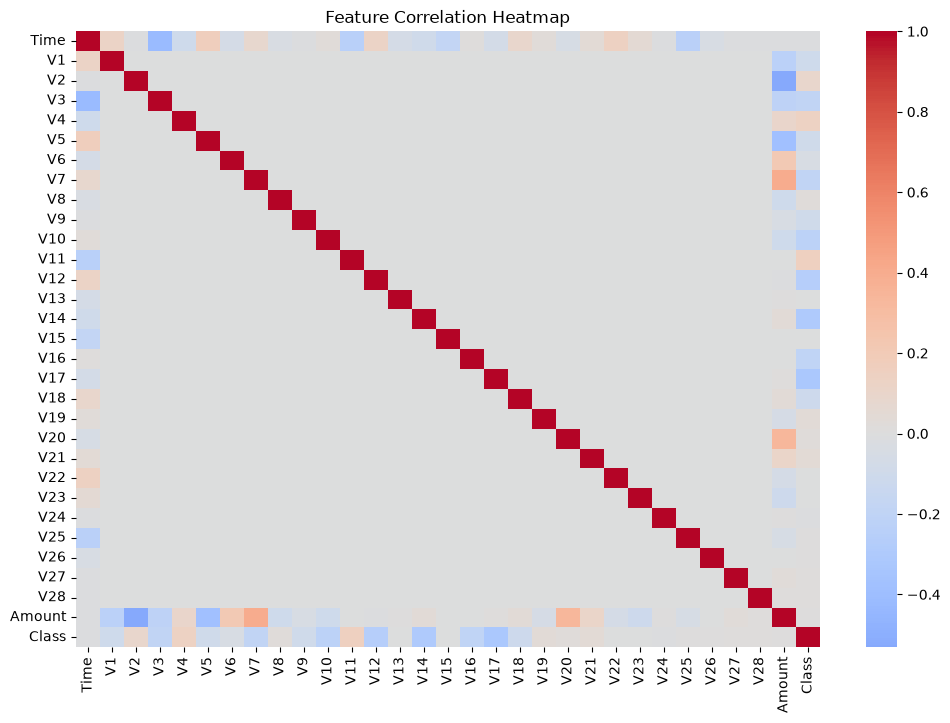

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()

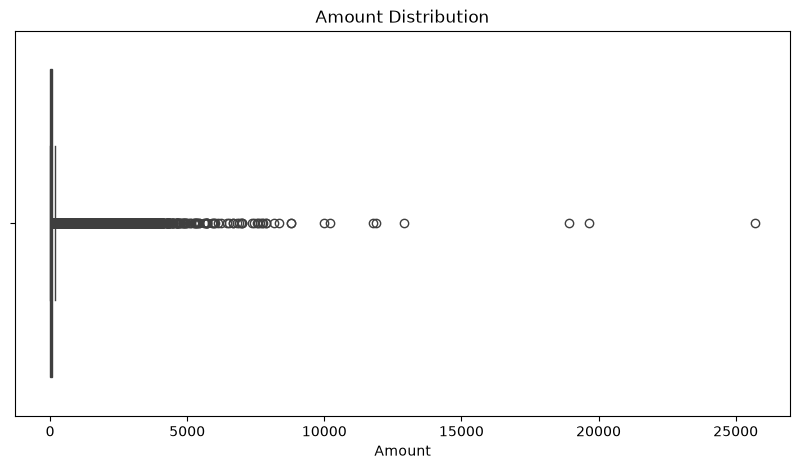

In [27]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["Amount"])

plt.title("Amount Distribution")
plt.show()


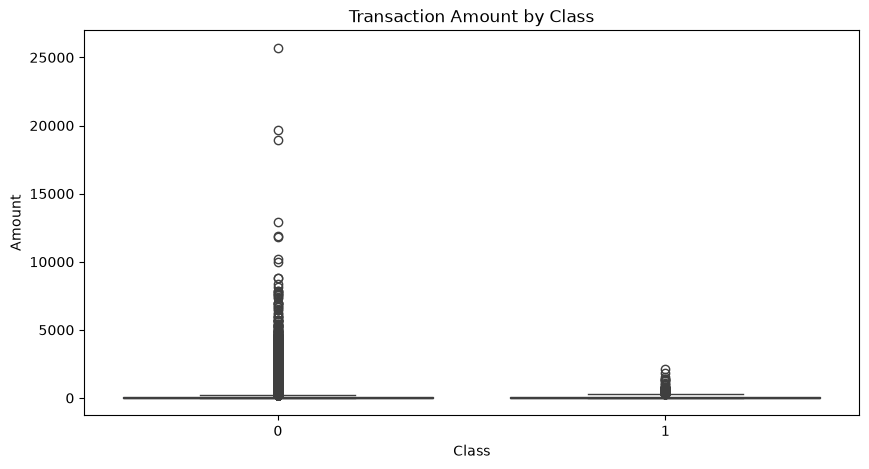

In [28]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df, x="Class", y="Amount")

plt.title("Transaction Amount by Class")
plt.show()

## Initial Dataset Findings

- Dataset contains 284,807 transactions and 31 columns.
- Target variable: `Class`.
- `Class = 0`: 284,315 transactions.
- `Class = 1`: 492 transactions.
- Fraud proportion: approximately 0.17%.
- No missing values were found.
- 1,081 duplicate rows were identified.
- `Time` and `Amount` are numerical features.
- `Amount` contains significant outliers.
- Features `V1` to `V28` show different relationships with the target.
- The dataset is highly imbalanced.

In [29]:
duplicate_rows = df[df.duplicated(keep=False)]

print(duplicate_rows.groupby("Class").size())

Class
0    1822
1      32
dtype: int64


In [30]:
print(
    duplicate_rows.groupby(["Class", "Amount"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)

Class  Amount
0      1.00      170
       150.00     28
       29.00      28
       0.76       26
       0.00       24
       1.51       22
       3.60       20
       7.56       18
       40.00      16
       1.18       14
dtype: int64


In [31]:
fraud_duplicates = df[
    df.duplicated(keep=False) & (df["Class"] == 1)
]

print("Fraud duplicate rows:", len(fraud_duplicates))
print("Unique fraud duplicate rows:", len(fraud_duplicates.drop_duplicates()))

Fraud duplicate rows: 32
Unique fraud duplicate rows: 13


In [32]:
print(fraud_duplicates.drop_duplicates()["Class"].value_counts())

Class
1    13
Name: count, dtype: int64


In [33]:
print(fraud_duplicates.drop_duplicates())

            Time         V1         V2         V3         V4         V5  \
102441   68207.0 -13.192671  12.785971  -9.906650   3.320337  -4.801176   
141257   84204.0  -0.937843   3.462889  -6.445104   4.932199  -2.233983   
141259   84204.0  -1.927453   1.827621  -7.019495   5.348303  -2.739188   
143333   85285.0  -7.030308   3.421991  -9.525072   5.270891  -4.024630   
143335   85285.0  -6.713407   3.921104  -9.746678   5.148263  -5.151563   
150660   93853.0  -6.185857   7.102985 -13.030455   8.010823  -7.885237   
150662   93853.0  -5.839192   7.151532 -12.816760   7.031115  -9.651272   
150666   93860.0 -10.850282   6.727466 -16.760583   8.425832 -10.252697   
150668   93860.0 -10.632375   7.251936 -17.681072   8.204144 -10.166591   
150677   93879.0 -13.086519   7.352148 -18.256576  10.648505 -11.731476   
150679   93879.0 -12.833631   7.508790 -20.491952   7.465780 -11.575304   
151006   94362.0 -26.457745  16.497472 -30.177317   8.904157 -17.892600   
234632  148053.0   1.2613

In [34]:
normal_duplicates = df[
    df.duplicated(keep=False) & (df["Class"] == 0)
]

print("Normal duplicate rows:", len(normal_duplicates))
print("Unique normal duplicate rows:", len(normal_duplicates.drop_duplicates()))

Normal duplicate rows: 1822
Unique normal duplicate rows: 760


In [35]:
duplicate_counts = df.value_counts()

print(duplicate_counts.value_counts().sort_index())

count
1     282953
2        611
3         66
4         81
5         10
6          1
9          2
18         2
Name: count, dtype: int64


In [36]:
df_no_duplicates = df.drop_duplicates()

print(df_no_duplicates["Class"].value_counts())
print(df_no_duplicates["Class"].value_counts(normalize=True))

Class
0    283253
1       473
Name: count, dtype: int64
Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64


In [37]:
print("Original rows:", len(df))
print("After removing duplicates:", len(df_no_duplicates))
print("Rows removed:", len(df) - len(df_no_duplicates))

Original rows: 284807
After removing duplicates: 283726
Rows removed: 1081


In [38]:
df = df.drop_duplicates().reset_index(drop=True)

print(df.shape)
print(df["Class"].value_counts())

(283726, 31)
Class
0    283253
1       473
Name: count, dtype: int64


In [39]:
print(df.isnull().sum().sum())

0


In [40]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [41]:
print(df.nunique().sort_values())

Class          2
Amount     32767
Time      124592
V1        275663
V4        275663
V5        275663
V2        275663
V3        275663
V8        275663
V9        275663
V10       275663
V11       275663
V12       275663
V13       275663
V6        275663
V7        275663
V15       275663
V14       275663
V16       275663
V17       275663
V20       275663
V21       275663
V18       275663
V19       275663
V23       275663
V22       275663
V24       275663
V25       275663
V27       275663
V26       275663
V28       275663
dtype: int64


In [42]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Series([], dtype: int64)


In [43]:
print(df.dtypes.value_counts())

float64    30
int64       1
Name: count, dtype: int64


In [44]:
import numpy as np

print("Infinite values:", np.isinf(df.select_dtypes(include=np.number)).sum().sum())

Infinite values: 0


In [45]:
print("Unique Time values:", df["Time"].nunique())
print("Total rows:", len(df))

Unique Time values: 124592
Total rows: 283726


In [46]:
print("Missing:", df["Time"].isnull().sum())
print("Negative:", (df["Time"] < 0).sum())
print("Zero:", (df["Time"] == 0).sum())

Missing: 0
Negative: 0
Zero: 2


In [47]:
print("Missing:", df["Amount"].isnull().sum())
print("Negative:", (df["Amount"] < 0).sum())
print("Zero:", (df["Amount"] == 0).sum())


Missing: 0
Negative: 0
Zero: 1808


In [48]:
print(df[df["Amount"] == 0]["Class"].value_counts())

Class
0    1783
1      25
Name: count, dtype: int64


In [49]:
print(df["Amount"].skew())

16.978803370060476


In [50]:
print(df.drop(columns="Class").skew().sort_values(ascending=False))

Amount    16.978803
V28       11.555115
V7         2.890271
V21        2.820033
V6         1.829880
V10        1.252967
V4         0.671504
V26        0.580292
V9         0.537663
V11        0.344074
V19        0.108312
V13        0.064293
Time      -0.035581
V22       -0.182330
V18       -0.248661
V15       -0.309659
V25       -0.415744
V24       -0.552129
V27       -0.753804
V16       -1.051161
V14       -1.918804
V20       -2.043121
V3        -2.151984
V12       -2.199008
V5        -2.414079
V1        -3.273271
V17       -3.690497
V2        -4.695162
V23       -5.867221
V8        -8.310970
dtype: float64


In [51]:
Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Amount"] < lower) | (df["Amount"] > upper)]

print("Lower bound:", lower)
print("Upper bound:", upper)
print("Outliers:", len(outliers))

Lower bound: -102.26500000000001
Upper bound: 185.375
Outliers: 31685


In [52]:
print(outliers["Class"].value_counts())

Class
0    31598
1       87
Name: count, dtype: int64


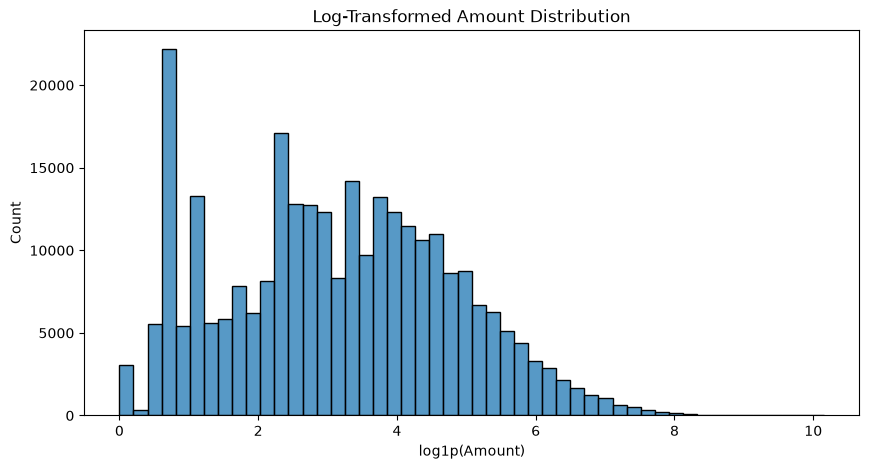

In [53]:
plt.figure(figsize=(10, 5))

sns.histplot(np.log1p(df["Amount"]), bins=50)

plt.title("Log-Transformed Amount Distribution")
plt.xlabel("log1p(Amount)")
plt.show()

In [54]:
df["LogAmount"] = np.log1p(df["Amount"])

print(df.groupby("Class")["LogAmount"].describe())

          count      mean       std  min       25%       50%       75%  \
Class                                                                    
0      283253.0  3.154289  1.655951  0.0  1.897620  3.135494  4.362589   
1         473.0  2.837549  2.212747  0.0  0.693147  2.381396  4.671800   

             max  
Class             
0      10.153941  
1       7.662407  


In [55]:
df.drop(columns=["LogAmount"], inplace=True)

print(df.shape)

(283726, 31)


## Data Cleaning Decisions

- Removed 1,081 exact duplicate rows.
- No missing values found.
- No infinite values found.
- No constant-value features found.
- Zero-amount transactions were retained.
- Amount outliers were retained because they may represent legitimate transactions.
- The dataset remains highly imbalanced and will be handled during modeling.

In [56]:
df.to_csv("../data/processed/cleaned_fraud_data.csv", index=False)

print("Saved:", df.shape)

Saved: (283726, 31)


In [57]:
import os

print(os.path.exists("../data/processed/cleaned_fraud_data.csv"))

True
